# Conditional vertical velocity and divergence through the mixed layer

This notebook creates:

1. A **1×3** conditional-mean vertical-velocity figure at **T = 0 days**.
2. A **3×3** conditional-mean divergence figure at **T = 0, 6, and 12 days**.

The columns represent approximately \(z/\mathrm{MLD}=0, 0.5, 1\). Physical depths are reconstructed from the prescribed MITgcm `delR` values rather than from NetCDF vertical coordinates that may contain only level indices.


In [9]:
from pathlib import Path
import sys
import importlib
import json

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in (PROJECT_DIR, FLOW_SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
case_name = "run_aug1"
RUN_TITLE_INFO = "Case AUG-1 Production"

DATA_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()

# Set this only when the full-MLD WVEL at T=0 is stored separately.
DATA_FILE_T0_W = None

OUT_DIR = (NB_DIR / f"../results/{case_name}").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
DOMAIN_JSON = OUT_DIR / f"{case_name}_domain_characterization.json"

SAVE = True
DX = 500.0
DY = 500.0
F0 = 8.0e-5
DAY_PER_INDEX = 0.5  # fallback when the time coordinate has no usable units

TARGET_DAYS = [0.0, 6.0, 12.0]
TARGET_MLD_FRACTIONS = [0.0, 0.5, 1.0]
TARGET_MLD_LABELS = ["0", "0.5", "1"]

# The first column uses the second U/V model layer, not the uppermost one.
NEAR_SURFACE_UV_INDEX = 1
# The first vertical-velocity panel uses the first W level below the surface.
NEAR_SURFACE_W_INDEX = 1

NBINS = 90
MIN_BIN_COUNT = 8
PERCENTILE_LIMIT = 98
W_TO_M_PER_DAY = True

# MITgcm layer thicknesses [m].
DELR = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8,
    5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4,
    12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2,
    29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8,
    70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5,
    167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5,
], dtype=float)

# Cell-center depths for U/V and interface depths for W.
UV_DEPTHS_M = np.cumsum(DELR) - 0.5 * DELR
W_DEPTHS_M = np.concatenate(([0.0], np.cumsum(DELR)))

plt.rcParams.update({
    "font.size": 17,
    "axes.titlesize": 19,
    "axes.labelsize": 19,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.titlesize": 22,
})

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find dataset:\n{DATA_FILE}")
if not DOMAIN_JSON.exists():
    raise FileNotFoundError(f"Could not find domain characterization:\n{DOMAIN_JSON}")

with DOMAIN_JSON.open("r", encoding="utf-8") as f:
    MLD_MEAN_M = float(json.load(f)["mld_mean_m"])

print(f"Dataset  : {DATA_FILE}")
print(f"Mean MLD : {MLD_MEAN_M:.2f} m")


Dataset  : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\data\input\run_aug1.nc
Mean MLD : 16.81 m


In [10]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def open_case(path):
    ds = xr.open_dataset(path, chunks="auto")
    time_dim = shu.find_dim(ds.dims, ["T", "time", "iter"])
    z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])
    w_dim = (
        shu.find_dim(ds["WVEL"].dims, ["Zl", "Z", "Zmd", "k", "depth"])
        if "WVEL" in ds else None
    )
    return ds, time_dim, z_dim, w_dim


def uv_depths_for(ds, z_dim):
    n = ds.sizes[z_dim]
    if n > UV_DEPTHS_M.size:
        raise ValueError("U/V dataset has more vertical levels than DELR defines.")
    return UV_DEPTHS_M[:n]


def w_depths_for(ds, w_dim):
    n = ds.sizes[w_dim]
    # WVEL should normally be on vertical interfaces. If only the upper subset
    # was saved, the first n interface depths are still the corresponding depths.
    if n > W_DEPTHS_M.size:
        raise ValueError("WVEL dataset has more vertical levels than DELR defines.")
    return W_DEPTHS_M[:n]


def nearest_index(depths, target, min_index=0):
    return int(np.argmin(np.abs(depths[min_index:] - target)) + min_index)


def select_uv_indices(depths):
    return [
        NEAR_SURFACE_UV_INDEX,
        nearest_index(depths, 0.5 * MLD_MEAN_M, NEAR_SURFACE_UV_INDEX),
        nearest_index(depths, 1.0 * MLD_MEAN_M, NEAR_SURFACE_UV_INDEX),
    ]


def select_w_indices(depths):
    return [
        NEAR_SURFACE_W_INDEX,
        nearest_index(depths, 0.5 * MLD_MEAN_M, NEAR_SURFACE_W_INDEX),
        nearest_index(depths, 1.0 * MLD_MEAN_M, NEAR_SURFACE_W_INDEX),
    ]


def get_time_index(ds, time_dim, target_day):
    values = np.asarray(ds[time_dim].values)
    try:
        if np.issubdtype(values.dtype, np.timedelta64):
            days = values / np.timedelta64(1, "D")
        elif np.issubdtype(values.dtype, np.datetime64):
            days = (values - values[0]) / np.timedelta64(1, "D")
        else:
            units = str(ds[time_dim].attrs.get("units", "")).lower()
            if "second" in units or units == "s":
                days = (values.astype(float) - float(values[0])) / 86400.0
            elif "hour" in units:
                days = (values.astype(float) - float(values[0])) / 24.0
            else:
                raise ValueError
    except Exception:
        days = np.arange(ds.sizes[time_dim]) * DAY_PER_INDEX

    days = np.asarray(days, dtype=float)
    idx = int(np.argmin(np.abs(days - target_day)))
    return idx, float(days[idx])


def common_edges(fields):
    ro_all = np.concatenate([ro[np.isfinite(ro)] for ro, _, _ in fields])
    st_all = np.concatenate([st[np.isfinite(st)] for _, st, _ in fields])

    x0, x1 = np.nanpercentile(ro_all, [0.2, 99.8])
    y0, y1 = np.nanpercentile(st_all, [0.2, 99.8])
    xpad = 0.04 * (x1 - x0)
    ypad = 0.04 * (y1 - y0)

    return (
        np.linspace(x0 - xpad, x1 + xpad, NBINS + 1),
        np.linspace(max(0.0, y0 - ypad), y1 + ypad, NBINS + 1),
    )


def conditioned_mean(ro, strain, value, ro_edges, strain_edges):
    value, ro, strain = shu.crop_to_common_shape(value, ro, strain)
    mask = np.isfinite(value) & np.isfinite(ro) & np.isfinite(strain)
    mean, count = shu.conditioned_mean_2d(
        ro[mask], strain[mask], value[mask], ro_edges, strain_edges
    )
    mean = np.asarray(mean, dtype=float)
    mean[count < MIN_BIN_COUNT] = np.nan
    return mean


def shared_symmetric_limit(fields):
    finite = [np.abs(a[np.isfinite(a)]) for a in fields if np.any(np.isfinite(a))]
    if not finite:
        return 1.0
    values = np.concatenate(finite)
    limit = np.nanpercentile(values, PERCENTILE_LIMIT)
    return 1.0 if not np.isfinite(limit) or limit == 0 else float(limit)


def draw_panel(ax, field, x_edges, y_edges, limit, title=""):
    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        field.T,
        shading="auto",
        cmap=shu.get_cmap("conditional"),
        vmin=-limit,
        vmax=limit,
    )
    xx = np.linspace(x_edges[0], x_edges[-1], 500)
    ax.plot(
        xx,
        np.abs(xx),
        "--",
        color=shu.get_color("reference"),
        lw=1.5,
        alpha=0.8,
    )
    shu.add_regime_labels(ax, x_edges, y_edges)
    shu.format_axis(ax, title=title, grid=True, equal=False)
    return pcm


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\conditional_w_t0_three_mld_depths_run_aug1.png


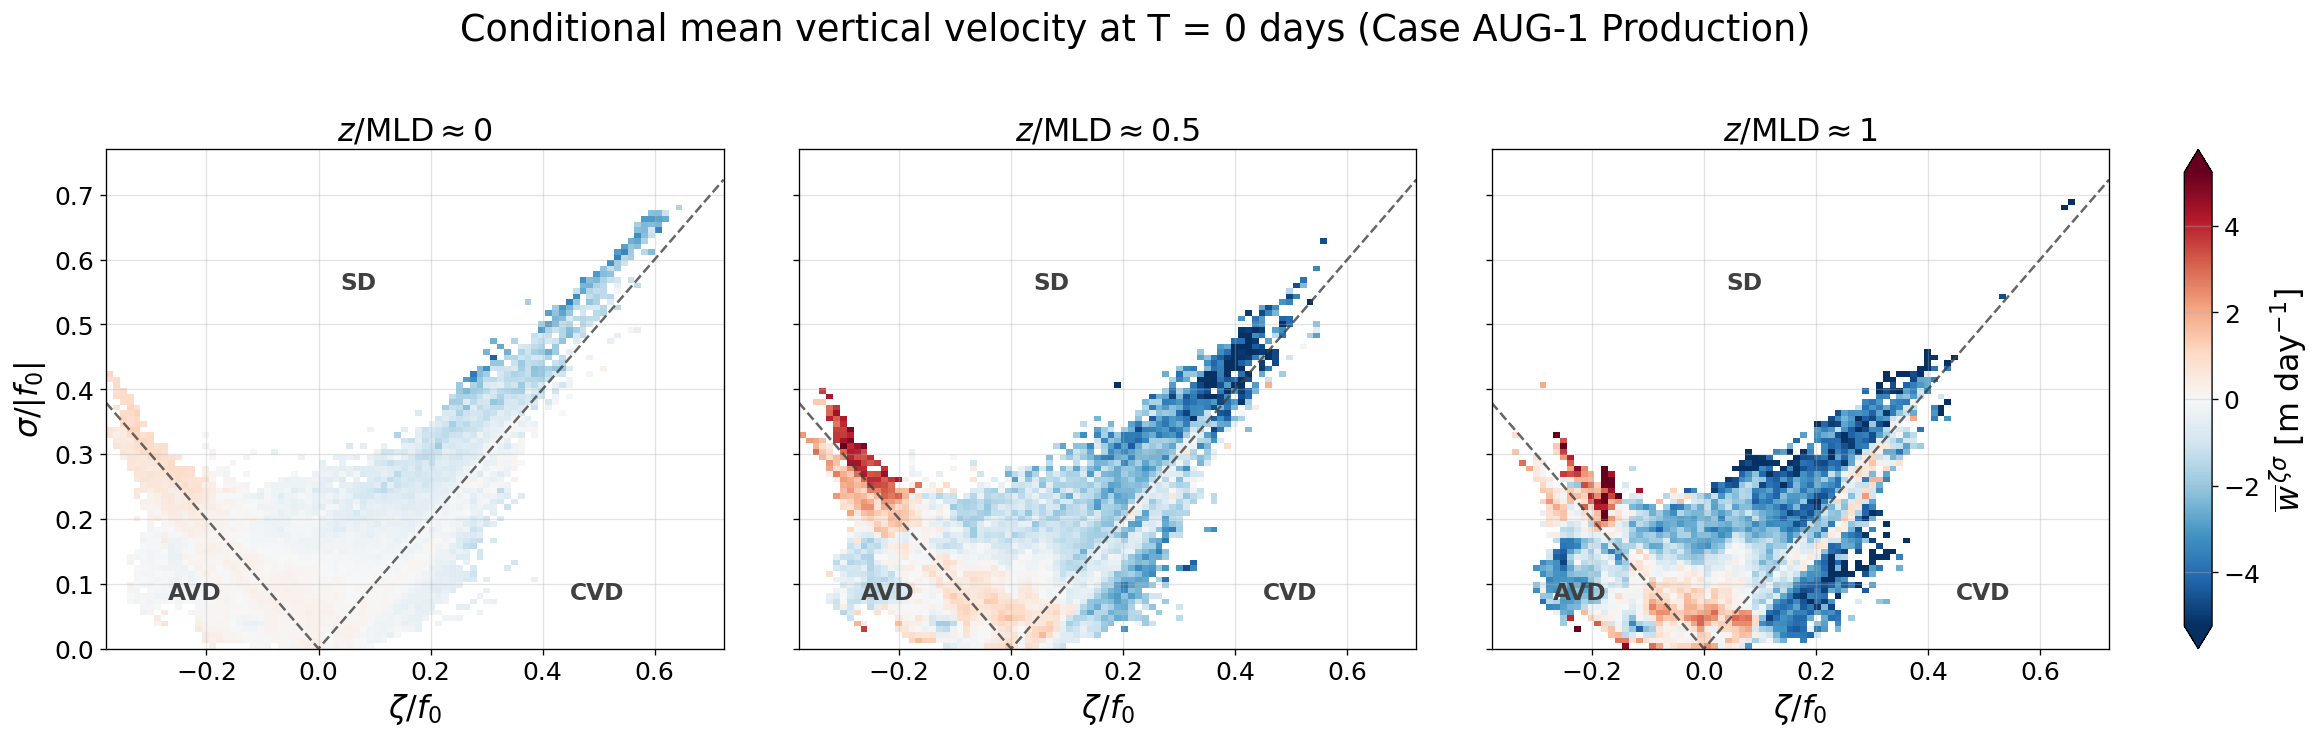

Selected physical depths for Figure 1:
  z/MLD≈0: U/V index 1 at 3.0 m; W index 1 at 2.0 m
  z/MLD≈0.5: U/V index 4 at 9.0 m; W index 4 at 8.0 m
  z/MLD≈1: U/V index 8 at 17.0 m; W index 8 at 16.0 m


In [11]:
# ------------------------------------------------------------
# FIGURE 1: conditional signed W at T=0
# ------------------------------------------------------------
w_path = DATA_FILE if DATA_FILE_T0_W is None else Path(DATA_FILE_T0_W).resolve()
if not w_path.exists():
    raise FileNotFoundError(f"Could not find T=0 W dataset:\n{w_path}")

ds_w, time_dim_w, z_dim_w, w_dim = open_case(w_path)
if w_dim is None:
    raise KeyError("WVEL is required for Figure 1.")

uv_depths = uv_depths_for(ds_w, z_dim_w)
w_depths = w_depths_for(ds_w, w_dim)
uv_indices = select_uv_indices(uv_depths)
w_indices = select_w_indices(w_depths)
it0, day0 = get_time_index(ds_w, time_dim_w, 0.0)

raw = []
for kuv, kw in zip(uv_indices, w_indices):
    ro, _, strain = shu.compute_surface_kinematics(
        ds_w, time_dim_w, z_dim_w, it0, [kuv], DX, DY, F0
    )
    w = shu.clean_fill(ds_w["WVEL"].isel({time_dim_w: it0, w_dim: kw}).values)
    if W_TO_M_PER_DAY:
        w = w * 86400.0
    raw.append((ro, strain, w))

ro_edges, strain_edges = common_edges(raw)
W_cond = [conditioned_mean(ro, strain, w, ro_edges, strain_edges) for ro, strain, w in raw]
w_limit = shared_symmetric_limit(W_cond)

fig = plt.figure(figsize=(19.5, 6.4), facecolor="white")
gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.045],
    left=0.06,
    right=0.96,
    bottom=0.13,
    top=0.78,
    wspace=0.16,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(3)]
cax = fig.add_subplot(gs[0, 3])

for j, (ax, field) in enumerate(zip(axes, W_cond)):
    pcm = draw_panel(
        ax,
        field,
        ro_edges,
        strain_edges,
        w_limit,
        title=rf"$z/\mathrm{{MLD}}\approx {TARGET_MLD_LABELS[j]}$",
    )
    ax.set_xlabel(r"$\zeta/f_0$")
    if j == 0:
        ax.set_ylabel(r"$\sigma/|f_0|$")
    else:
        ax.tick_params(labelleft=False)

cbar = fig.colorbar(pcm, cax=cax, extend="both")
cbar.set_label(
    r"$\overline{w}^{\,\zeta\sigma}$ [m day$^{-1}$]"
    if W_TO_M_PER_DAY
    else r"$\overline{w}^{\,\zeta\sigma}$ [m s$^{-1}$]"
)

fig.suptitle(
    f"Conditional mean vertical velocity at T = {day0:g} days ({RUN_TITLE_INFO})",
    y=0.96,
)

shu.savefig_if_needed(
    fig,
    f"conditional_w_t0_three_mld_depths_{case_name}",
    save=SAVE,
    out_dir=OUT_DIR,
)
plt.show()

print("Selected physical depths for Figure 1:")
for label, kuv, kw in zip(TARGET_MLD_LABELS, uv_indices, w_indices):
    print(
        f"  z/MLD≈{label}: U/V index {kuv} at {uv_depths[kuv]:.1f} m; "
        f"W index {kw} at {w_depths[kw]:.1f} m"
    )


Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\conditional_divergence_3x3_mld_run_aug1.png


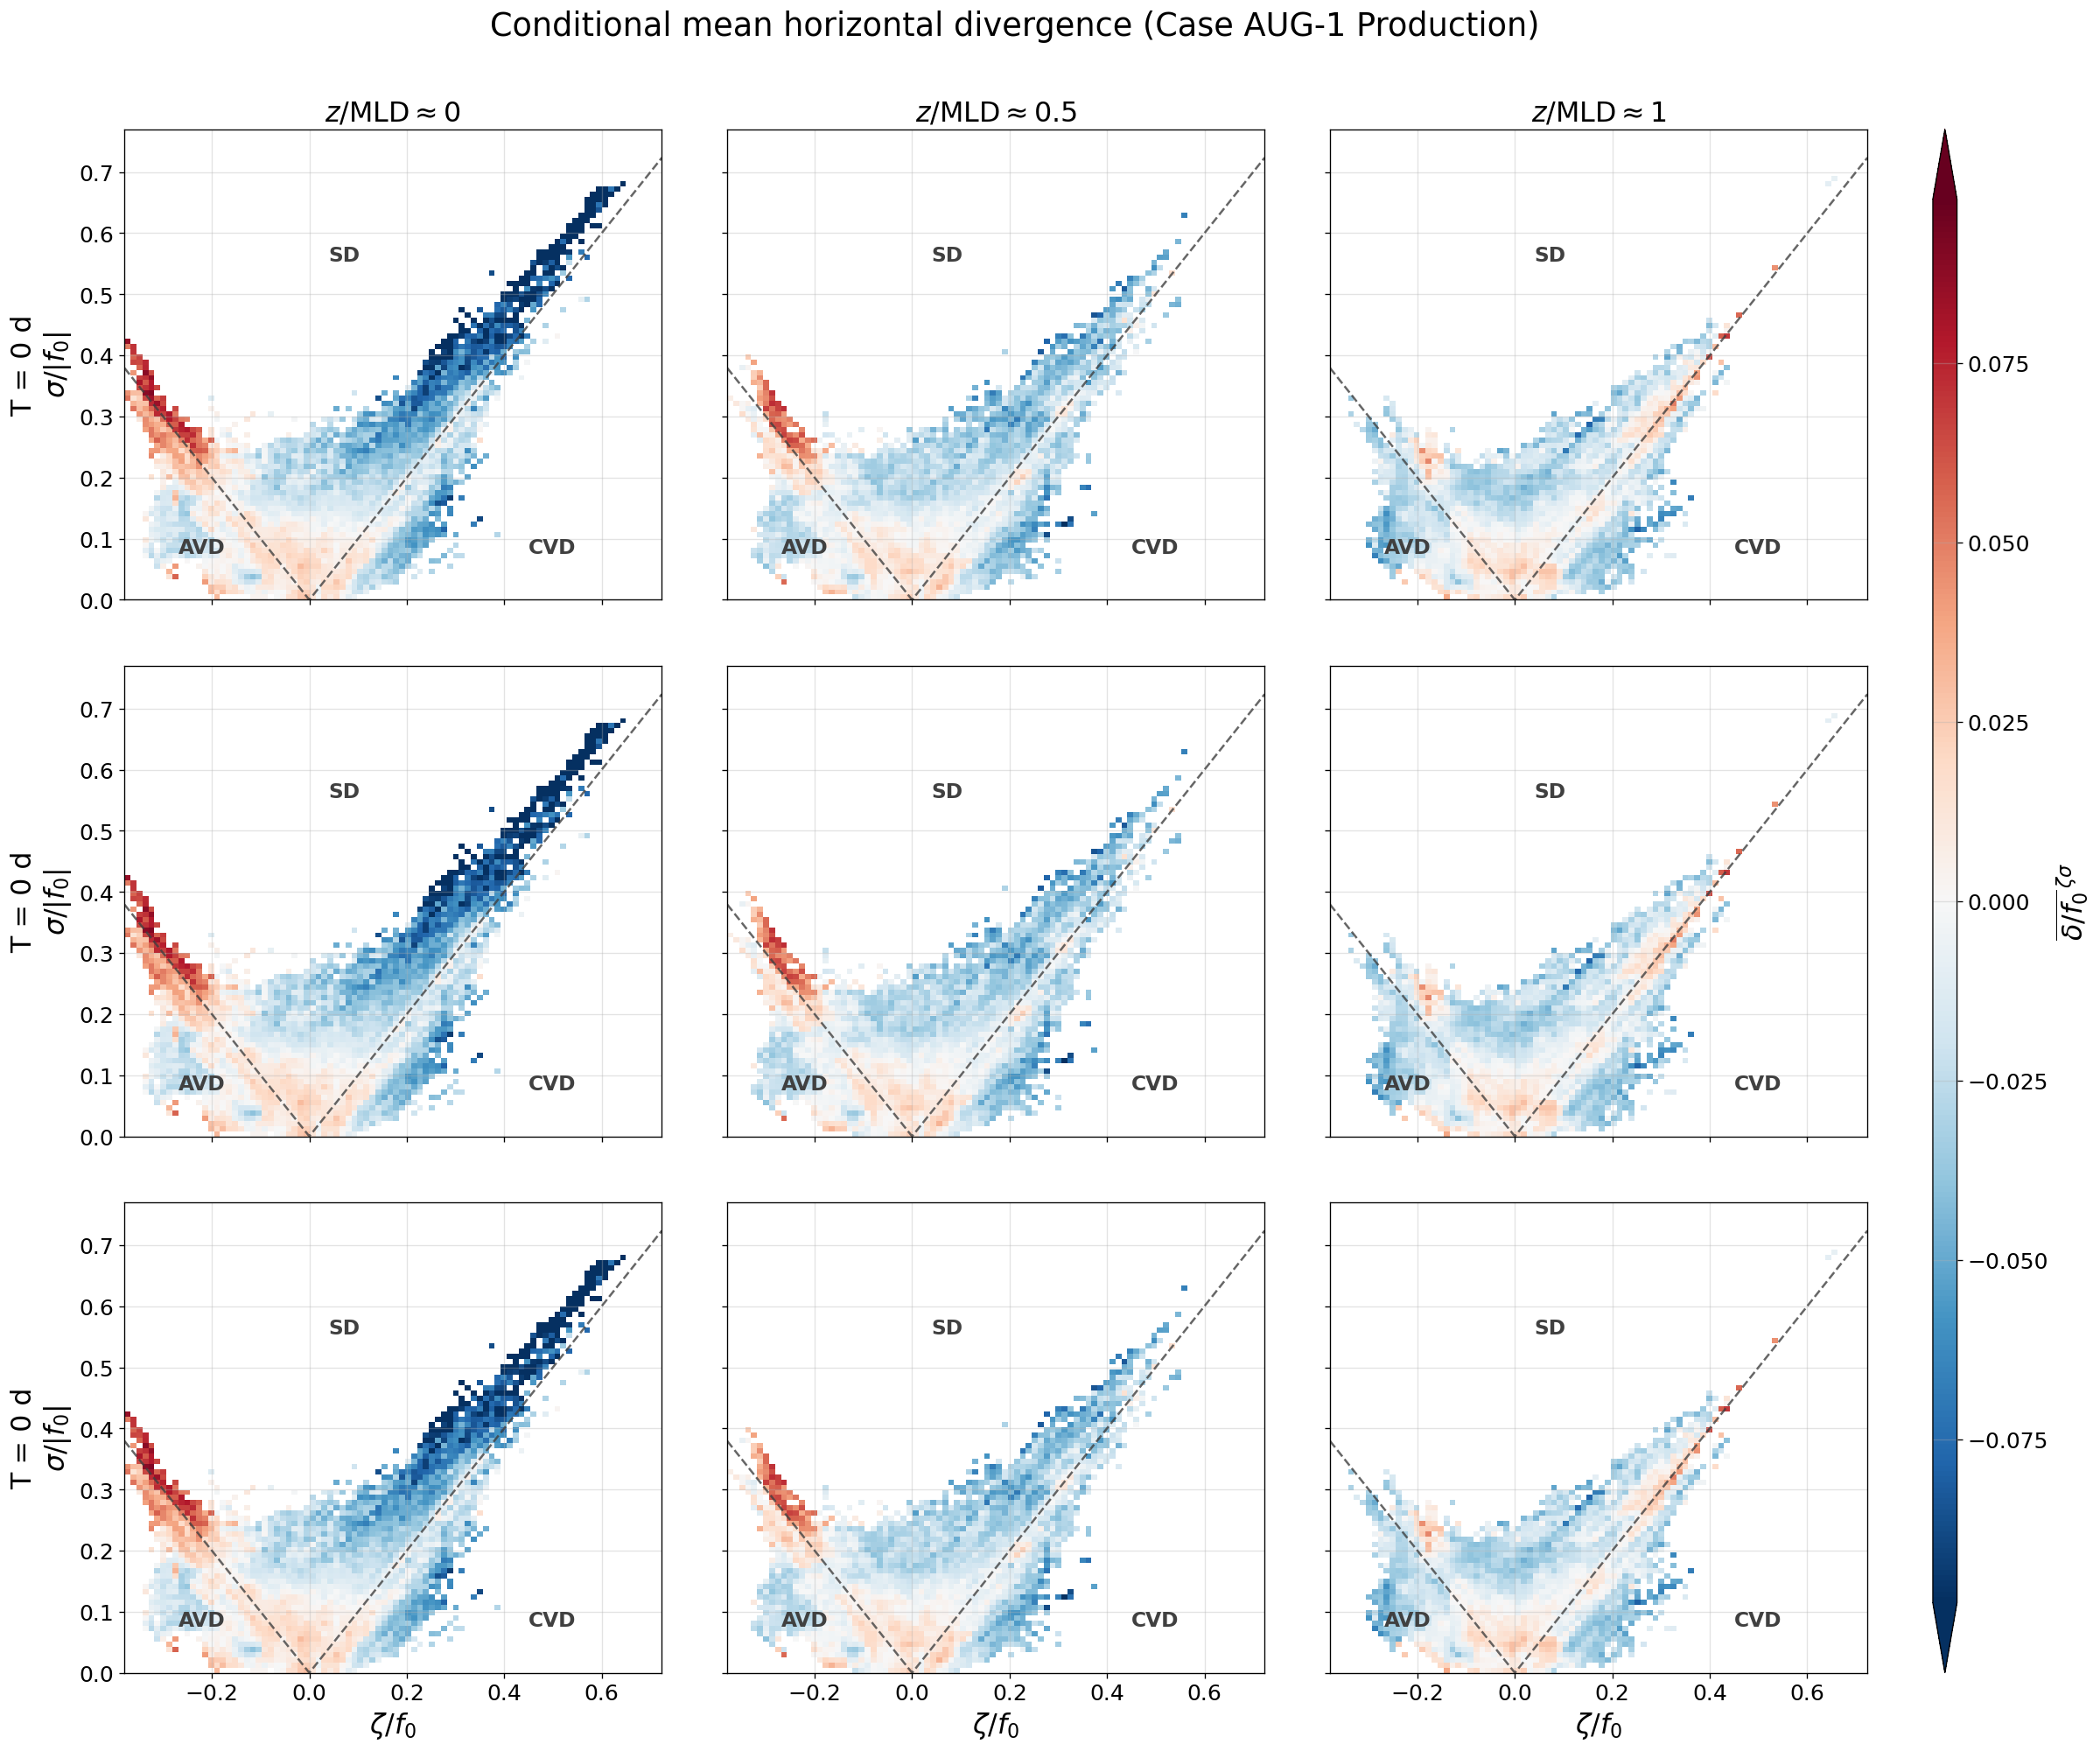

Selected times: [(0, 0.0), (0, 0.0), (0, 0.0)]
Selected physical U/V depths for Figure 2:
  z/MLD≈0: U/V index 1 at 3.0 m
  z/MLD≈0.5: U/V index 4 at 9.0 m
  z/MLD≈1: U/V index 8 at 17.0 m


In [12]:
# ------------------------------------------------------------
# FIGURE 2: conditional divergence at 3 times × 3 depths
# ------------------------------------------------------------
ds, time_dim, z_dim, _ = open_case(DATA_FILE)
uv_depths = uv_depths_for(ds, z_dim)
uv_indices = select_uv_indices(uv_depths)
selected_times = [get_time_index(ds, time_dim, day) for day in TARGET_DAYS]

raw = []
for it, actual_day in selected_times:
    for kuv in uv_indices:
        ro, div_f, strain = shu.compute_surface_kinematics(
            ds, time_dim, z_dim, it, [kuv], DX, DY, F0
        )
        raw.append((ro, strain, div_f, it, actual_day, kuv))

ro_edges, strain_edges = common_edges([(ro, strain, div) for ro, strain, div, *_ in raw])
D_cond = [
    conditioned_mean(ro, strain, div, ro_edges, strain_edges)
    for ro, strain, div, *_ in raw
]
d_limit = shared_symmetric_limit(D_cond)

fig = plt.figure(figsize=(19.5, 17.5), facecolor="white")
gs = fig.add_gridspec(
    3,
    4,
    width_ratios=[1, 1, 1, 0.045],
    left=0.065,
    right=0.96,
    bottom=0.07,
    top=0.91,
    wspace=0.16,
    hspace=0.14,
)
axes = np.array([[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(3)])
cax = fig.add_subplot(gs[:, 3])

for index, (field, (_, _, _, it, actual_day, kuv)) in enumerate(zip(D_cond, raw)):
    row, col = divmod(index, 3)
    ax = axes[row, col]
    title = rf"$z/\mathrm{{MLD}}\approx {TARGET_MLD_LABELS[col]}$" if row == 0 else ""
    pcm = draw_panel(ax, field, ro_edges, strain_edges, d_limit, title=title)

    if row == 2:
        ax.set_xlabel(r"$\zeta/f_0$")
    else:
        ax.tick_params(labelbottom=False)

    if col == 0:
        ax.set_ylabel(rf"T = {actual_day:g} d" + "\n" + r"$\sigma/|f_0|$")
    else:
        ax.tick_params(labelleft=False)

cbar = fig.colorbar(pcm, cax=cax, extend="both")
cbar.set_label(r"$\overline{\delta/f_0}^{\,\zeta\sigma}$")

fig.suptitle(
    f"Conditional mean horizontal divergence ({RUN_TITLE_INFO})",
    y=0.975,
)

shu.savefig_if_needed(
    fig,
    f"conditional_divergence_3x3_mld_{case_name}",
    save=SAVE,
    out_dir=OUT_DIR,
)
plt.show()

print("Selected times:", selected_times)
print("Selected physical U/V depths for Figure 2:")
for label, kuv in zip(TARGET_MLD_LABELS, uv_indices):
    print(f"  z/MLD≈{label}: U/V index {kuv} at {uv_depths[kuv]:.1f} m")
